# Analisi Clustering VeronaCard - Tourist Behavior Segmentation

Questo notebook analizza in dettaglio il clustering dei turisti basato sui loro pattern di visita ai POI di Verona.

## Obiettivi
1. Comprendere come funziona il clustering K-means applicato ai dati turistici
2. Estrarre e interpretare i centroidi dei cluster
3. Validare il numero ottimale di cluster
4. Visualizzare i cluster in spazi bidimensionali
5. Caratterizzare i diversi "tipi" di turisti
6. Confrontare clustering tra anni diversi

---
## 1. Setup e Import

In [21]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score, silhouette_samples, davies_bouldin_score
import warnings
warnings.filterwarnings('ignore')

# Configurazione visualizzazioni
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")
%matplotlib inline

print("✅ Import completati")

✅ Import completati


---
## 2. Caricamento e Preprocessing dei Dati

### 2.1 Funzioni di caricamento dati

In [22]:
def load_pois(filepath: Path) -> pd.DataFrame:
    """
    Carica i Points of Interest (POI) con coordinate geografiche.
    
    Returns:
        DataFrame con: name_short, latitude, longitude
    """
    df = pd.read_csv(
        filepath, 
        usecols=["name_short", "latitude", "longitude"],
        dtype={
            "name_short": "category",
            "latitude": np.float32,
            "longitude": np.float32
        }
    )
    print(f"📍 Caricati {len(df)} POI")
    return df

def load_visits(filepath: Path) -> pd.DataFrame:
    """
    Carica i dati delle visite turistiche.
    
    Returns:
        DataFrame con: timestamp, card_id, name_short
    """
    df = pd.read_csv(
        filepath,
        usecols=[0, 1, 2, 4],
        names=["data", "ora", "name_short", "card_id"],
        header=0,
        dtype={"card_id": "category", "name_short": "category"}
    )
    
    # Combina data e ora in timestamp
    df["timestamp"] = pd.to_datetime(
        df["data"] + " " + df["ora"], 
        format="%d-%m-%y %H:%M:%S"
    )
    
    result = df[["timestamp", "card_id", "name_short"]].sort_values("timestamp").reset_index(drop=True)
    print(f"🎫 Caricate {len(result):,} visite da {df.card_id.nunique():,} card")
    return result

def filter_multi_visit_cards(df: pd.DataFrame) -> pd.DataFrame:
    """
    Filtra per mantenere solo card con visite a POI multipli e distinti.
    """
    unique_pois_per_card = df.groupby("card_id")["name_short"].nunique()
    valid_cards = unique_pois_per_card[unique_pois_per_card > 1].index
    
    filtered = df[df["card_id"].isin(valid_cards)].reset_index(drop=True)
    print(f"✂️  Filtrate {len(valid_cards):,} card multi-visita ({len(valid_cards)/df.card_id.nunique()*100:.1f}%)")
    return filtered

def find_visit_files(data_dir: Path) -> list:
    """
    Trova tutti i file CSV delle visite (escludendo vc_site.csv).
    
    Returns:
        Lista ordinata di file CSV da processare
    """
    all_csv = list(data_dir.glob("*.csv"))
    visit_files = [
        f for f in all_csv 
        if f.name.lower() != "vc_site.csv" and "backup" not in f.name.lower()
    ]
    return sorted(visit_files)

print("✅ Funzioni di caricamento definite")

✅ Funzioni di caricamento definite


### 2.2 Ricerca file disponibili e caricamento POI

In [23]:
# Path configurabili
DATA_DIR = Path("../data/verona")
POI_FILE = DATA_DIR / "vc_site.csv"

# Trova tutti i file di visite disponibili
visit_files = find_visit_files(DATA_DIR)

print(f"\n📂 File trovati in {DATA_DIR}:")
print(f"   - POI file: {POI_FILE.name}")
print(f"   - Visit files trovati: {len(visit_files)}")
for vf in visit_files:
    print(f"      • {vf.name}")

if not visit_files:
    raise ValueError(f"Nessun file di visite trovato in {DATA_DIR}")

# Carica POI (unico per tutti gli anni)
pois_df = load_pois(POI_FILE)

print("\n✅ File identificati")


📂 File trovati in ../data/verona:
   - POI file: vc_site.csv
   - Visit files trovati: 12
      • dati_2014.csv
      • dati_2015.csv
      • dati_2016.csv
      • dati_2017.csv
      • dati_2018.csv
      • dati_2019.csv
      • dati_2020.csv
      • veronacard_2019_original.csv
      • veronacard_2020_original.csv
      • veronacard_2021_original.csv
      • veronacard_2022_original.csv
      • veronacard_2023_original_parziale.csv
📍 Caricati 22 POI

✅ File identificati


---
## 3. Loop su tutti i file: Clustering Multi-Anno

Eseguiamo il clustering per ogni anno disponibile e salviamo i risultati separatamente.

In [24]:
# Configurazione clustering
K_FINAL = 7  # Numero di cluster
K_RANGE = range(2, 16)  # Range per validazione
TOP_N = 10  # Top POI da analizzare

# Directory output
OUTPUT_BASE_DIR = Path("../results/clustering_analysis")
OUTPUT_BASE_DIR.mkdir(exist_ok=True, parents=True)

# Dizionario per raccogliere risultati multi-anno
all_years_results = {}

print(f"\n{'='*100}")
print(f"🔄 INIZIO CLUSTERING MULTI-ANNO")
print(f"{'='*100}")
print(f"Configurazione: K={K_FINAL}, Validazione K={K_RANGE.start}-{K_RANGE.stop-1}")
print(f"File da processare: {len(visit_files)}\n")


🔄 INIZIO CLUSTERING MULTI-ANNO
Configurazione: K=7, Validazione K=2-15
File da processare: 12



### 3.1 Processamento File Iterativo

Per ogni file di visite, eseguiamo l'intera pipeline di clustering.

In [25]:
for file_idx, visits_file in enumerate(visit_files, 1):
    
    # Estrai anno dal nome file (es: dati_2017.csv -> 2017)
    year = visits_file.stem.split('_')[-1] if '_' in visits_file.stem else visits_file.stem
    
    print(f"\n{'#'*100}")
    print(f"📅 PROCESSAMENTO FILE {file_idx}/{len(visit_files)}: {visits_file.name} (Anno: {year})")
    print(f"{'#'*100}\n")
    
    # === CARICAMENTO DATI ===
    print("📥 Caricamento dati...")
    visits_df = load_visits(visits_file)
    merged_df = visits_df.merge(pois_df[["name_short"]], on="name_short", how="inner")
    print(f"🔗 Visite valide dopo merge: {len(merged_df):,}")
    filtered_df = filter_multi_visit_cards(merged_df)
    
    # === CREAZIONE MATRICE USER-POI ===
    print("\n📊 Creazione matrice User-POI...")
    user_poi_matrix = pd.crosstab(filtered_df["card_id"], filtered_df["name_short"])
    print(f"   - Dimensioni: {user_poi_matrix.shape[0]:,} turisti × {user_poi_matrix.shape[1]} POI")
    print(f"   - Sparsità: {(user_poi_matrix == 0).sum().sum() / user_poi_matrix.size * 100:.1f}% zeri")
    print(f"   - Visite medie: {user_poi_matrix.sum(axis=1).mean():.2f}")
    
    # === STANDARDIZZAZIONE ===
    print("\n⚖️  Standardizzazione dati...")
    scaler = StandardScaler()
    scaled_matrix = scaler.fit_transform(user_poi_matrix)
    print(f"   ✅ Matrice standardizzata: media≈0, std≈1")
    
    # === VALIDAZIONE K (opzionale, solo per primo file) ===
    if file_idx == 1:
        print("\n🔍 Validazione numero cluster (solo primo file)...")
        inertias = []
        silhouette_scores = []
        davies_bouldin_scores = []
        
        for k in K_RANGE:
            kmeans_temp = KMeans(n_clusters=k, random_state=42, n_init=10, max_iter=300)
            labels_temp = kmeans_temp.fit_predict(scaled_matrix)
            inertias.append(kmeans_temp.inertia_)
            silhouette_scores.append(silhouette_score(scaled_matrix, labels_temp))
            davies_bouldin_scores.append(davies_bouldin_score(scaled_matrix, labels_temp))
        
        print(f"   ✅ Metriche calcolate per K={K_RANGE.start} a {K_RANGE.stop-1}")
    
    # === CLUSTERING FINALE ===
    print(f"\n🎯 Clustering K-Means (K={K_FINAL})...")
    kmeans_final = KMeans(
        n_clusters=K_FINAL,
        random_state=42,
        n_init=10,
        max_iter=300
    )
    clusters = kmeans_final.fit_predict(scaled_matrix)
    
    user_clusters = pd.DataFrame({
        "card_id": user_poi_matrix.index,
        "cluster": clusters
    })
    
    print(f"   ✅ Clustering completato")
    print(f"   - Inertia: {kmeans_final.inertia_:,.0f}")
    print(f"   - Silhouette: {silhouette_score(scaled_matrix, clusters):.4f}")
    print(f"   - Iterazioni: {kmeans_final.n_iter_}")
    
    # Distribuzione cluster
    cluster_sizes = user_clusters['cluster'].value_counts().sort_index()
    print(f"\n   📊 Distribuzione turisti:")
    for cid, count in cluster_sizes.items():
        print(f"      Cluster {cid}: {count:6,} ({count/len(user_clusters)*100:5.1f}%)")
    
    # === ESTRAZIONE CENTROIDI ===
    print(f"\n📍 Estrazione centroidi...")
    centroids_scaled = kmeans_final.cluster_centers_
    centroids_original = scaler.inverse_transform(centroids_scaled)
    centroids_df = pd.DataFrame(
        centroids_original,
        columns=user_poi_matrix.columns,
        index=[str(i) for i in range(K_FINAL)]  # ✅ Solo numeri
    )
    print(f"   ✅ Centroidi de-standardizzati: {centroids_df.shape}")
    
    # Analisi top POI per cluster
    cluster_profiles = {}
    for cluster_id in range(K_FINAL):
        centroid_values = centroids_df.iloc[cluster_id]
        top_pois = centroid_values.nlargest(TOP_N)
        
        cluster_data = user_poi_matrix.iloc[clusters == cluster_id]
        cluster_profiles[cluster_id] = {
            'n_tourists': int((clusters == cluster_id).sum()),
            'top_pois': {str(k): float(v) for k, v in top_pois.to_dict().items()},
            'avg_total_visits': float(cluster_data.sum(axis=1).mean()),
            'avg_unique_pois': float((cluster_data > 0).sum(axis=1).mean())
        }
    
    # === PCA ===
    print(f"\n🔬 PCA per visualizzazione...")
    pca = PCA(n_components=2, random_state=42)
    coords_2d = pca.fit_transform(scaled_matrix)
    user_clusters['PC1'] = coords_2d[:, 0]
    user_clusters['PC2'] = coords_2d[:, 1]
    print(f"   ✅ Varianza spiegata: {sum(pca.explained_variance_ratio_)*100:.2f}%")
    
    # === SALVATAGGIO RISULTATI ===
    print(f"\n💾 Salvataggio risultati per anno {year}...")
    year_output_dir = OUTPUT_BASE_DIR / f"year_{year}"
    year_output_dir.mkdir(exist_ok=True, parents=True)
    
    # 1. Centroidi
    centroids_df.to_csv(year_output_dir / "cluster_centroids.csv")
    
    # 2. Assegnazioni
    user_clusters.to_csv(year_output_dir / "user_cluster_assignments.csv", index=False)
    
    # 3. Summary
    summary_data = []
    for cid, profile in cluster_profiles.items():
        summary_data.append({
            'Cluster': cid,
            'N_Turisti': profile['n_tourists'],
            'Percentuale': f"{profile['n_tourists']/len(user_clusters)*100:.1f}%",
            'Visite_Medie': f"{profile['avg_total_visits']:.1f}",
            'POI_Distinti': f"{profile['avg_unique_pois']:.1f}",
            'Top_POI': list(profile['top_pois'].keys())[0]
        })
    summary_df = pd.DataFrame(summary_data)
    summary_df.to_csv(year_output_dir / "cluster_summary.csv", index=False)
    
    # 4. Metriche (solo primo anno)
    if file_idx == 1:
        metrics_df = pd.DataFrame({
            'K': list(K_RANGE),
            'Inertia': inertias,
            'Silhouette': silhouette_scores,
            'Davies_Bouldin': davies_bouldin_scores
        })
        metrics_df.to_csv(year_output_dir / "validation_metrics.csv", index=False)
    
    print(f"   ✅ Risultati salvati in: {year_output_dir}")
    
    # === SALVA RISULTATI GLOBALI ===
    all_years_results[year] = {
        'n_tourists': len(user_clusters),
        'n_visits': len(filtered_df),
        'silhouette': silhouette_score(scaled_matrix, clusters),
        'cluster_sizes': cluster_sizes.to_dict(),
        'centroids': centroids_df,
        'year_dir': year_output_dir
    }
    
    print(f"\n{'='*100}")
    print(f"✅ Completato processamento anno {year}")
    print(f"{'='*100}")

print(f"\n\n{'#'*100}")
print(f"🎉 CLUSTERING MULTI-ANNO COMPLETATO")
print(f"{'#'*100}")
print(f"\nAnni processati: {len(all_years_results)}")
print(f"Directory output: {OUTPUT_BASE_DIR}\n")


####################################################################################################
📅 PROCESSAMENTO FILE 1/12: dati_2014.csv (Anno: 2014)
####################################################################################################

📥 Caricamento dati...
🎫 Caricate 370,377 visite da 71,557 card
🔗 Visite valide dopo merge: 370,377
✂️  Filtrate 70,236 card multi-visita (98.2%)

📊 Creazione matrice User-POI...
   - Dimensioni: 70,236 turisti × 21 POI
   - Sparsità: 75.1% zeri
   - Visite medie: 5.25

⚖️  Standardizzazione dati...
   ✅ Matrice standardizzata: media≈0, std≈1

🔍 Validazione numero cluster (solo primo file)...
   ✅ Metriche calcolate per K=2 a 15

🎯 Clustering K-Means (K=7)...
   ✅ Clustering completato
   - Inertia: 1,082,002
   - Silhouette: 0.0767
   - Iterazioni: 26

   📊 Distribuzione turisti:
      Cluster 0: 19,490 ( 27.7%)
      Cluster 1:  2,240 (  3.2%)
      Cluster 2: 15,422 ( 22.0%)
      Cluster 3: 18,990 ( 27.0%)
      Cluster 4: 13,508

---
## 4. Confronto Multi-Anno

Confrontiamo i risultati del clustering tra i diversi anni.

In [26]:
# Crea tabella comparativa
comparison_data = []
for year, results in all_years_results.items():
    comparison_data.append({
        'Anno': year,
        'N. Turisti': f"{results['n_tourists']:,}",
        'N. Visite': f"{results['n_visits']:,}",
        'Silhouette': f"{results['silhouette']:.4f}",
        'Cluster Maggiore': max(results['cluster_sizes'], key=results['cluster_sizes'].get),
        'Size Maggiore': f"{max(results['cluster_sizes'].values()):,}"
    })

comparison_df = pd.DataFrame(comparison_data)
print("\n" + "="*100)
print("📊 CONFRONTO CLUSTERING MULTI-ANNO")
print("="*100)
display(comparison_df)

# Salva confronto
comparison_df.to_csv(OUTPUT_BASE_DIR / "multi_year_comparison.csv", index=False)
print(f"\n✅ Confronto salvato: {OUTPUT_BASE_DIR / 'multi_year_comparison.csv'}")


📊 CONFRONTO CLUSTERING MULTI-ANNO


,Anno,N. Turisti,N. Visite,Silhouette,Cluster Maggiore,Size Maggiore
0,2014,"70,236","369,017",0.0767,0,"19,490"
1,2015,"71,759","367,905",0.0999,1,"31,064"
2,2016,"76,452","381,791",0.1267,1,"31,821"
3,2017,"89,352","439,369",0.1138,0,"33,636"
4,2018,"86,222","424,793",0.0802,2,"27,185"
5,2019,"77,583","395,302",0.1143,4,"24,900"
6,2020,"7,658","38,035",0.1072,3,"2,358"
7,original,"84,988","376,551",0.1249,3,"31,109"
8,parziale,"12,240","57,449",0.1332,0,"4,652"



✅ Confronto salvato: ../results/clustering_analysis/multi_year_comparison.csv


### 4.1 Visualizzazione Confronto Silhouette Score

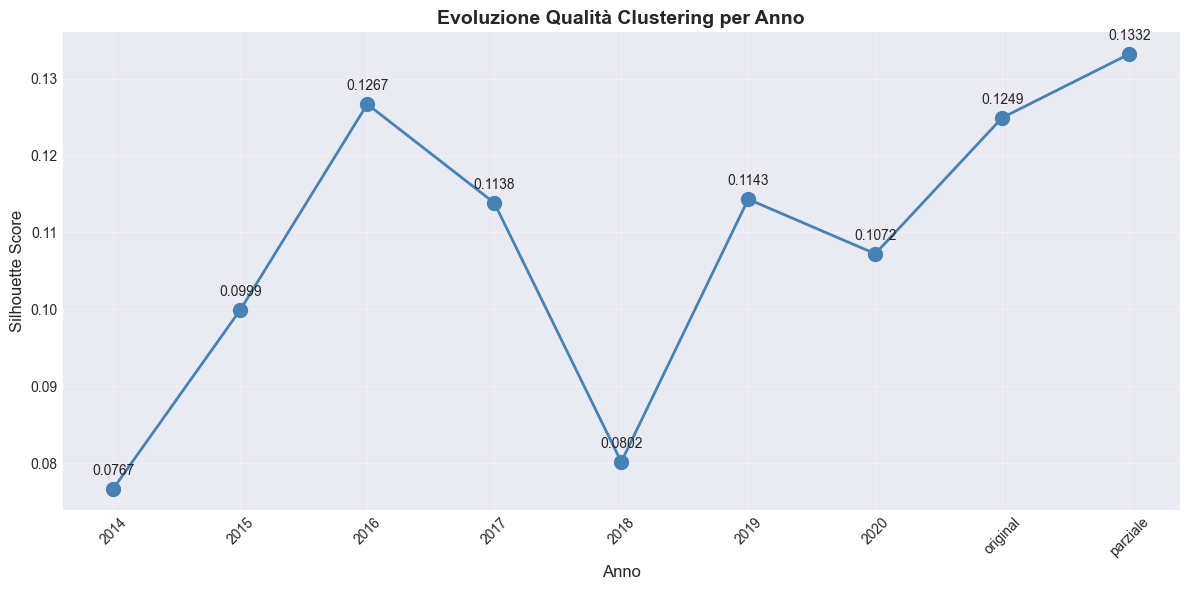

✅ Grafico salvato: ../results/clustering_analysis/silhouette_evolution.png


In [27]:
# Plot Silhouette scores per anno
years_list = [y for y in all_years_results.keys()]
silhouette_list = [all_years_results[y]['silhouette'] for y in years_list]

plt.figure(figsize=(12, 6))
plt.plot(years_list, silhouette_list, 'o-', linewidth=2, markersize=10, color='steelblue')
plt.xlabel('Anno', fontsize=12)
plt.ylabel('Silhouette Score', fontsize=12)
plt.title('Evoluzione Qualità Clustering per Anno', fontsize=14, fontweight='bold')
plt.grid(True, alpha=0.3)
plt.xticks(rotation=45)

# Aggiungi valori sui punti
for year, score in zip(years_list, silhouette_list):
    plt.annotate(f'{score:.4f}', (year, score), 
                textcoords="offset points", xytext=(0,10), ha='center')

plt.tight_layout()
plt.savefig(OUTPUT_BASE_DIR / "silhouette_evolution.png", dpi=300, bbox_inches='tight')
plt.show()

print(f"✅ Grafico salvato: {OUTPUT_BASE_DIR / 'silhouette_evolution.png'}")

### 4.2 Visualizzazione Distribuzione Cluster per Anno

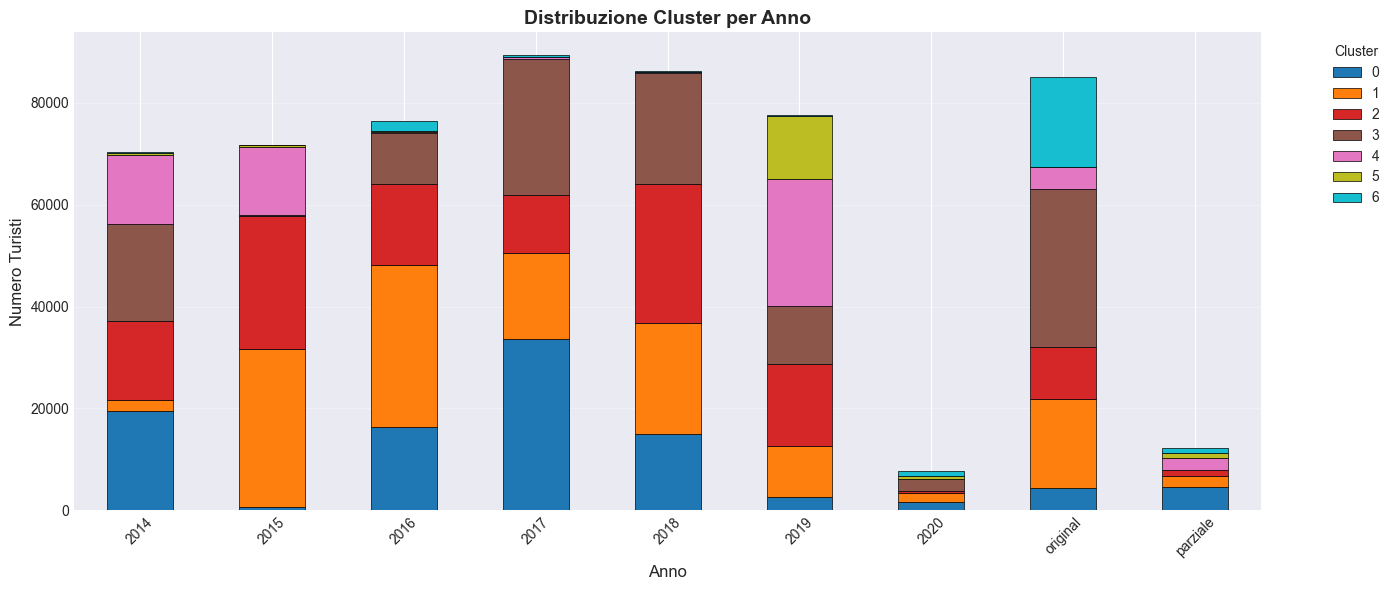

✅ Grafico salvato: ../results/clustering_analysis/cluster_distribution_years.png


In [28]:
# Stacked bar chart delle distribuzioni cluster
fig, ax = plt.subplots(figsize=(14, 6))

# Prepara dati
cluster_distribution = {}
for year, results in all_years_results.items():
    cluster_distribution[year] = results['cluster_sizes']

# Crea DataFrame per plotting
dist_df = pd.DataFrame(cluster_distribution).T
dist_df = dist_df.fillna(0)

# Plot stacked bar
dist_df.plot(kind='bar', stacked=True, ax=ax, colormap='tab10', edgecolor='black', linewidth=0.5)

ax.set_xlabel('Anno', fontsize=12)
ax.set_ylabel('Numero Turisti', fontsize=12)
ax.set_title('Distribuzione Cluster per Anno', fontsize=14, fontweight='bold')
ax.legend(title='Cluster', bbox_to_anchor=(1.05, 1), loc='upper left')
ax.grid(True, alpha=0.3, axis='y')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig(OUTPUT_BASE_DIR / "cluster_distribution_years.png", dpi=300, bbox_inches='tight')
plt.show()

print(f"✅ Grafico salvato: {OUTPUT_BASE_DIR / 'cluster_distribution_years.png'}")

---
## 5. Visualizzazione Dettagliata (Ultimo Anno Processato)

Mostriamo visualizzazioni dettagliate per l'ultimo anno analizzato.

In [29]:
# Seleziona ultimo anno
last_year = list(all_years_results.keys())[-1]
last_results = all_years_results[last_year]

print(f"\n📅 Visualizzazioni dettagliate per anno: {last_year}")
print(f"   Directory: {last_results['year_dir']}")

# Ricarica dati per plotting
centroids_plot = last_results['centroids']
cluster_sizes_plot = pd.Series(last_results['cluster_sizes'])


📅 Visualizzazioni dettagliate per anno: parziale
   Directory: ../results/clustering_analysis/year_parziale


### 5.1 Distribuzione Cluster (Ultimo Anno)

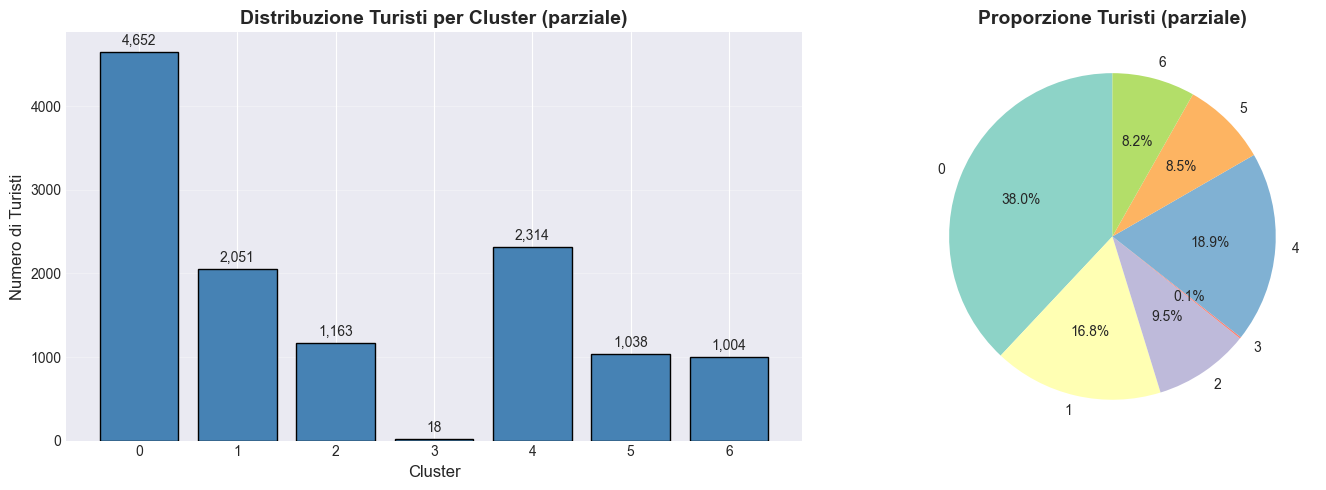

In [30]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Bar chart
axes[0].bar(cluster_sizes_plot.index, cluster_sizes_plot.values, color='steelblue', edgecolor='black')
axes[0].set_xlabel('Cluster', fontsize=12)  # ✅ Etichetta semplificata
axes[0].set_ylabel('Numero di Turisti', fontsize=12)
axes[0].set_title(f'Distribuzione Turisti per Cluster ({last_year})', fontsize=14, fontweight='bold')
axes[0].grid(True, alpha=0.3, axis='y')
for i, v in enumerate(cluster_sizes_plot.values):
    axes[0].text(cluster_sizes_plot.index[i], v + 50, f'{v:,}', ha='center', va='bottom', fontsize=10)

# Pie chart
colors = plt.cm.Set3(range(K_FINAL))
axes[1].pie(cluster_sizes_plot.values, 
            labels=[str(i) for i in cluster_sizes_plot.index],  # ✅ Solo numeri
            autopct='%1.1f%%', colors=colors, startangle=90)
axes[1].set_title(f'Proporzione Turisti ({last_year})', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.savefig(last_results['year_dir'] / "cluster_distribution.png", dpi=300, bbox_inches='tight')
plt.show()

### 5.2 Heatmap Centroidi (Ultimo Anno)

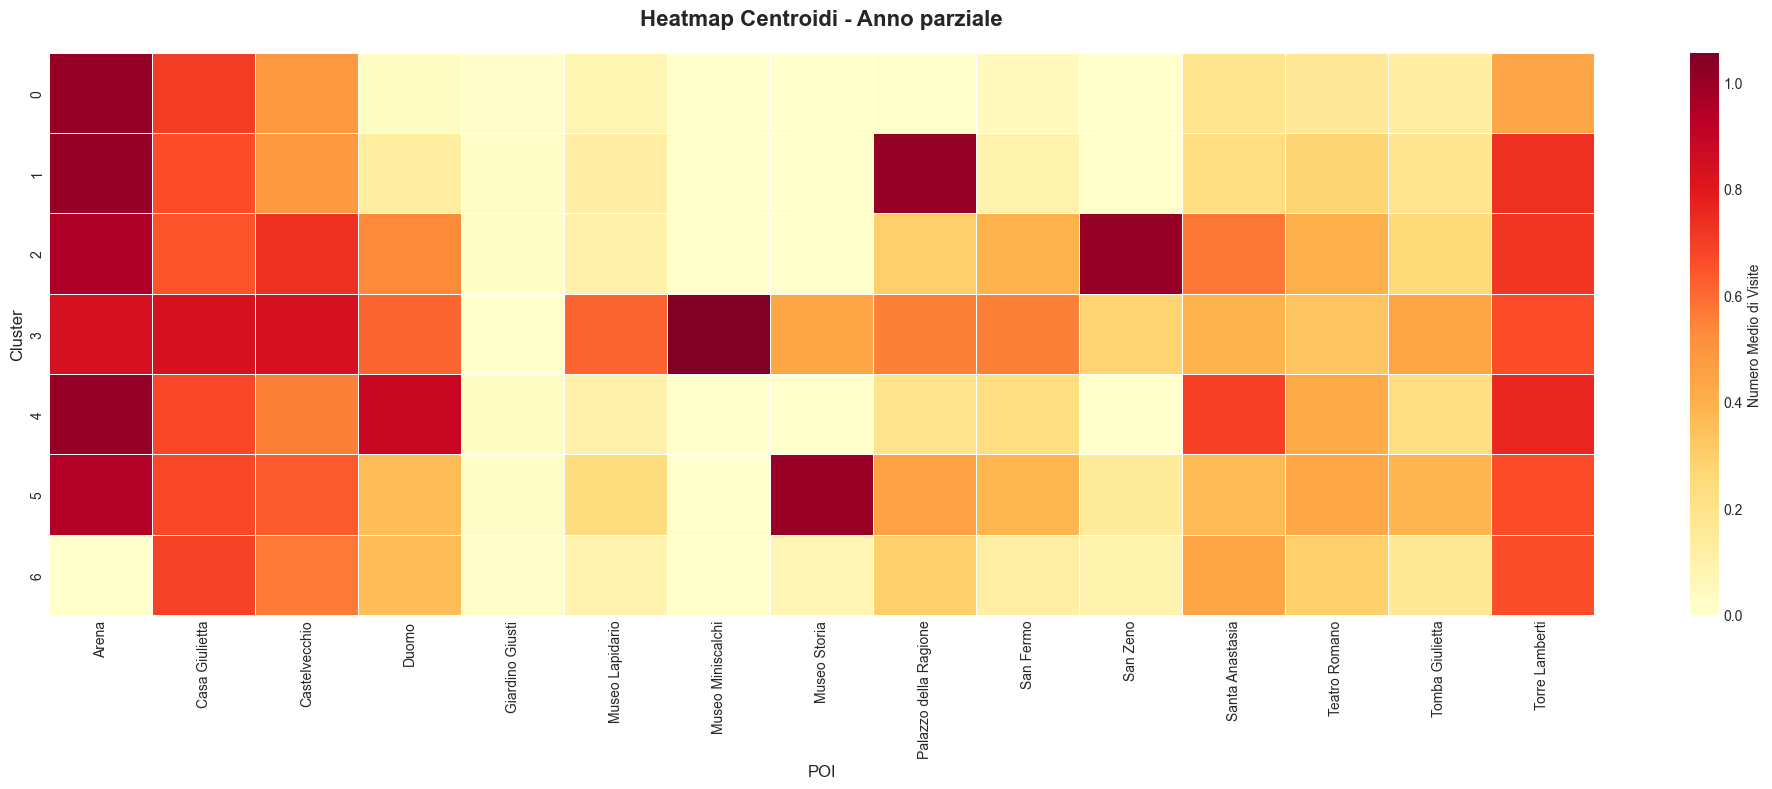

In [31]:
# Heatmap completa
plt.figure(figsize=(20, 8))
sns.heatmap(
    centroids_plot,
    cmap='YlOrRd',
    annot=False,
    fmt='.2f',
    linewidths=0.5,
    cbar_kws={'label': 'Numero Medio di Visite'},
    yticklabels=[str(i) for i in range(K_FINAL)]  # ✅ Solo numeri
)
plt.title(f'Heatmap Centroidi - Anno {last_year}', fontsize=16, fontweight='bold', pad=20)
plt.xlabel('POI', fontsize=12)
plt.ylabel('Cluster', fontsize=12)
plt.xticks(rotation=90)
plt.tight_layout()
plt.savefig(last_results['year_dir'] / "centroids_heatmap.png", dpi=300, bbox_inches='tight')
plt.show()

### 5.3 Radar Chart Pattern POI (Ultimo Anno)

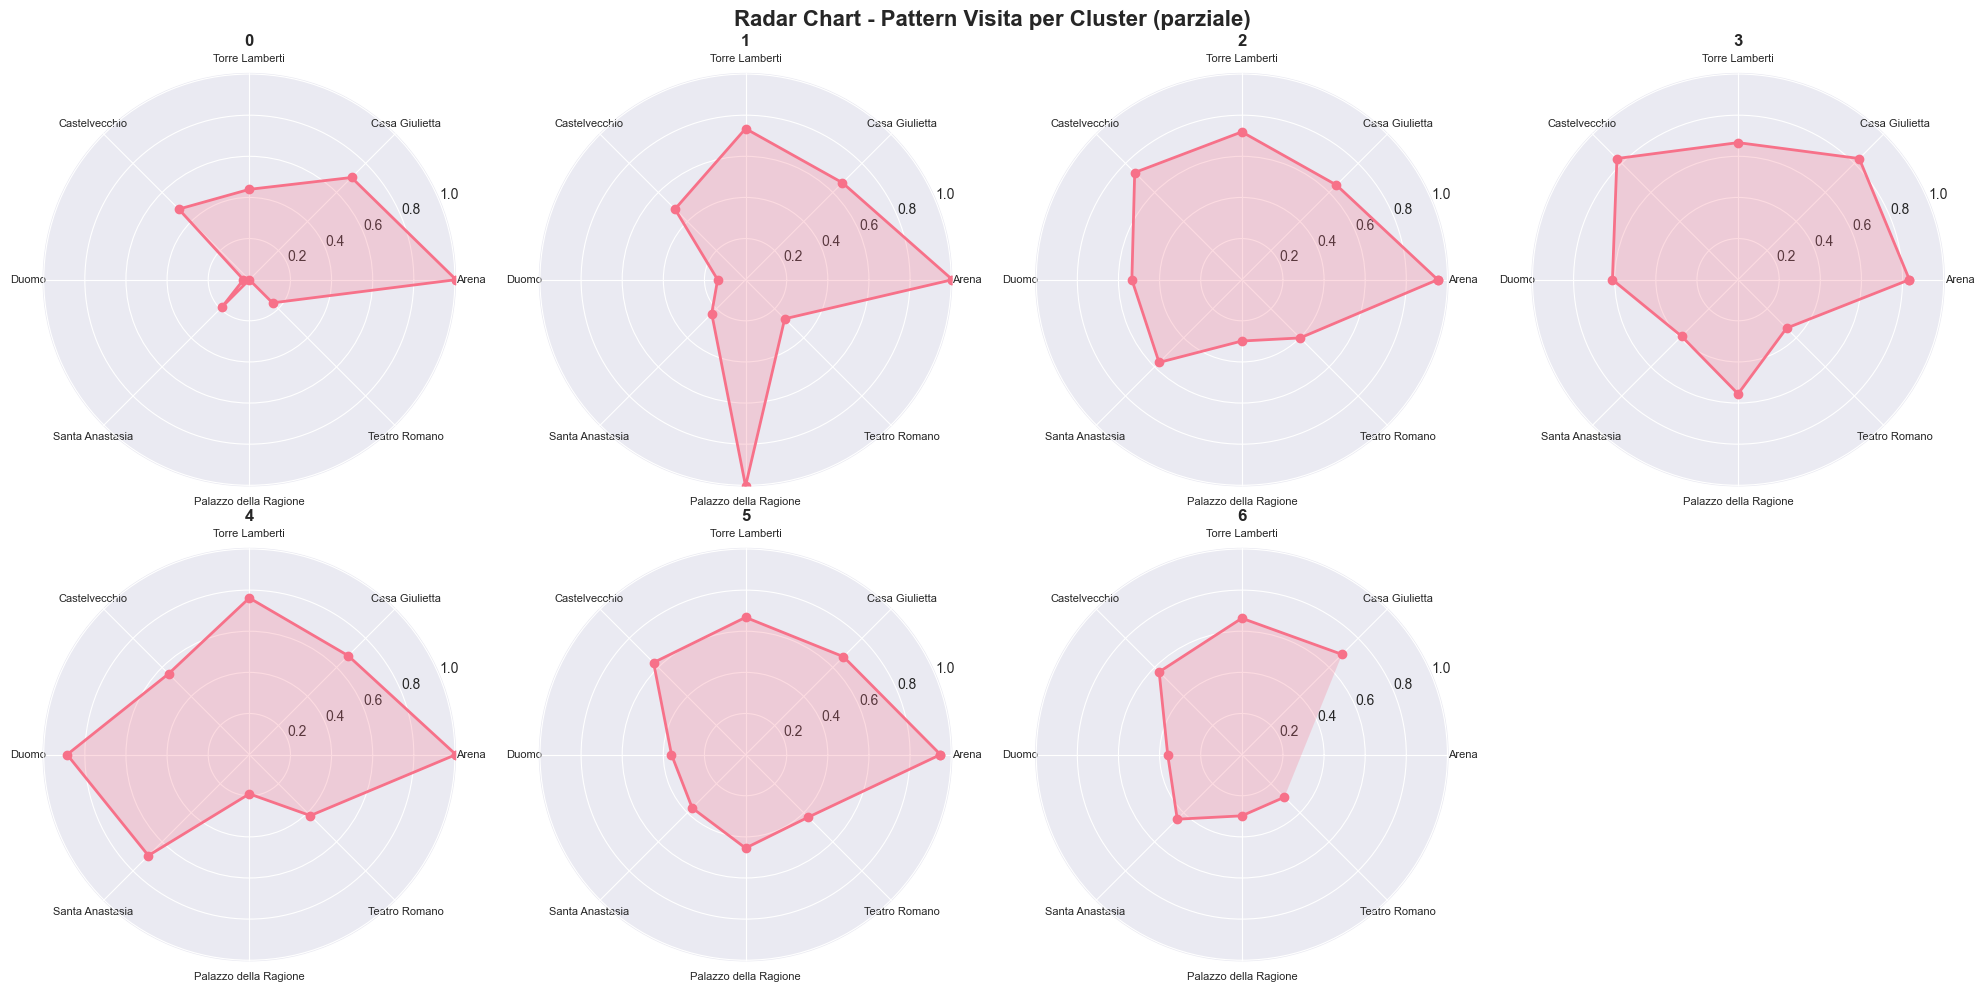

In [32]:
from math import pi

# Seleziona top 8 POI
top_8_pois = centroids_plot.sum(axis=0).nlargest(8).index

fig, axes = plt.subplots(2, 4, figsize=(20, 10), subplot_kw=dict(projection='polar'))
axes = axes.flatten()

categories = top_8_pois.tolist()
N = len(categories)
angles = [n / float(N) * 2 * pi for n in range(N)]
angles += angles[:1]

for cluster_id in range(K_FINAL):
    values = centroids_plot.loc[str(cluster_id), top_8_pois].values.tolist()
    values += values[:1]
    
    axes[cluster_id].plot(angles, values, 'o-', linewidth=2, label=f'{cluster_id}')  # ✅ Solo numero
    axes[cluster_id].fill(angles, values, alpha=0.25)
    axes[cluster_id].set_xticks(angles[:-1])
    axes[cluster_id].set_xticklabels(categories, size=8)
    axes[cluster_id].set_ylim(0, centroids_plot[top_8_pois].max().max())
    axes[cluster_id].set_title(f'{cluster_id}', fontsize=12, fontweight='bold', pad=20)  # ✅ Solo numero
    axes[cluster_id].grid(True)

axes[-1].axis('off')

plt.suptitle(f'Radar Chart - Pattern Visita per Cluster ({last_year})', fontsize=16, fontweight='bold', y=0.98)
plt.tight_layout()
plt.savefig(last_results['year_dir'] / "radar_charts.png", dpi=300, bbox_inches='tight')
plt.show()

---
## 6. Report HTML Multi-Anno

In [33]:
# Genera report HTML complessivo
html_report = f"""
<!DOCTYPE html>
<html>
<head>
    <title>VeronaCard Clustering Multi-Year Report</title>
    <style>
        body {{ font-family: Arial, sans-serif; margin: 40px; }}
        h1 {{ color: #2c3e50; }}
        h2 {{ color: #34495e; border-bottom: 2px solid #3498db; padding-bottom: 10px; }}
        table {{ border-collapse: collapse; width: 100%; margin: 20px 0; }}
        th, td {{ border: 1px solid #ddd; padding: 12px; text-align: left; }}
        th {{ background-color: #3498db; color: white; }}
        tr:nth-child(even) {{ background-color: #f2f2f2; }}
        .metric {{ background-color: #e8f4f8; padding: 15px; margin: 10px 0; border-radius: 5px; }}
        .year-section {{ border-left: 4px solid #3498db; padding-left: 20px; margin: 30px 0; }}
    </style>
</head>
<body>
    <h1>🎯 VeronaCard Tourist Clustering Analysis - Multi-Year Report</h1>
    
    <div class="metric">
        <h2>📊 Overview</h2>
        <ul>
            <li><b>Years Analyzed:</b> {len(all_years_results)}</li>
            <li><b>Clustering Algorithm:</b> K-Means (K={K_FINAL})</li>
            <li><b>Total Files Processed:</b> {len(visit_files)}</li>
        </ul>
    </div>
    
    <h2>📈 Multi-Year Comparison</h2>
    {comparison_df.to_html(index=False, border=0)}
"""

for year, results in all_years_results.items():
    html_report += f"""
    <div class="year-section">
        <h2>📅 Year {year}</h2>
        <p><b>Tourists:</b> {results['n_tourists']:,} | <b>Visits:</b> {results['n_visits']:,} | <b>Silhouette:</b> {results['silhouette']:.4f}</p>
        <h3>Cluster Distribution</h3>
        <ul>
    """
    for cid, size in results['cluster_sizes'].items():
        html_report += f"<li>Cluster {cid}: {size:,} tourists</li>"
    html_report += "</ul></div>"

html_report += """
</body>
</html>
"""

with open(OUTPUT_BASE_DIR / "multi_year_report.html", 'w') as f:
    f.write(html_report)

print(f"\n✅ Report HTML salvato: {OUTPUT_BASE_DIR / 'multi_year_report.html'}")
print(f"🌐 Apri il file nel browser per visualizzare il report completo!")


✅ Report HTML salvato: ../results/clustering_analysis/multi_year_report.html
🌐 Apri il file nel browser per visualizzare il report completo!


---
## 7. Riepilogo Finale

In [34]:
print("="*100)
print("🎉 ANALISI CLUSTERING COMPLETATA")
print("="*100)

print(f"\n📊 Statistiche Complessive:")
print(f"   - Anni processati: {len(all_years_results)}")
print(f"   - File analizzati: {len(visit_files)}")
print(f"   - Cluster per anno: {K_FINAL}")
print(f"   - Output directory: {OUTPUT_BASE_DIR}")

print(f"\n📁 File generati per ogni anno:")
print(f"   ✅ cluster_centroids.csv - Centroidi de-standardizzati")
print(f"   ✅ user_cluster_assignments.csv - Assegnazioni card→cluster con PCA")
print(f"   ✅ cluster_summary.csv - Summary statistico dei cluster")
print(f"   ✅ validation_metrics.csv - Metriche K=2..15 (solo primo anno)")
print(f"   ✅ Grafici PNG (distribuzione, heatmap, radar)")

print(f"\n📁 File multi-anno:")
print(f"   ✅ multi_year_comparison.csv - Confronto tra anni")
print(f"   ✅ multi_year_report.html - Report HTML completo")
print(f"   ✅ silhouette_evolution.png - Evoluzione qualità clustering")
print(f"   ✅ cluster_distribution_years.png - Distribuzione cluster per anno")

print(f"\n💡 Prossimi Passi:")
print(f"   1. Esplora i risultati in: {OUTPUT_BASE_DIR}")
print(f"   2. Apri multi_year_report.html nel browser")
print(f"   3. Confronta centroidi tra anni diversi")
print(f"   4. Usa i cluster per migliorare le predizioni LLM")

print("\n" + "="*100)
print("✅ Analisi completata con successo!")
print("="*100)

🎉 ANALISI CLUSTERING COMPLETATA

📊 Statistiche Complessive:
   - Anni processati: 9
   - File analizzati: 12
   - Cluster per anno: 7
   - Output directory: ../results/clustering_analysis

📁 File generati per ogni anno:
   ✅ cluster_centroids.csv - Centroidi de-standardizzati
   ✅ user_cluster_assignments.csv - Assegnazioni card→cluster con PCA
   ✅ cluster_summary.csv - Summary statistico dei cluster
   ✅ validation_metrics.csv - Metriche K=2..15 (solo primo anno)
   ✅ Grafici PNG (distribuzione, heatmap, radar)

📁 File multi-anno:
   ✅ multi_year_comparison.csv - Confronto tra anni
   ✅ multi_year_report.html - Report HTML completo
   ✅ silhouette_evolution.png - Evoluzione qualità clustering
   ✅ cluster_distribution_years.png - Distribuzione cluster per anno

💡 Prossimi Passi:
   1. Esplora i risultati in: ../results/clustering_analysis
   2. Apri multi_year_report.html nel browser
   3. Confronta centroidi tra anni diversi
   4. Usa i cluster per migliorare le predizioni LLM

✅ An